# CME/CBOT Corn Sep 2026 (ZCU26)

This notebook focuses on one real, tradable contract. It fetches the
historical OHLCV and open-interest data for ZCU26 from Barchart, draws
candlesticks, and adds causal streaming indicators from Screamer.

The chart uses only actual data for this named contract. It does not stitch
multiple contracts together, so ZCU26 remains the same contract throughout.

In [1]:
from pathlib import Path
import sys

candidate_roots = [Path.cwd(), *Path.cwd().parents]
repo_root = next(
    (candidate for candidate in candidate_roots if (candidate / "Barchart").is_dir()),
    None,
)
if repo_root is None:
    raise RuntimeError("Run this demo from a checkout containing the Barchart folder.")
sys.path.insert(0, str(repo_root))

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import screamer
from IPython.display import display
from matplotlib.patches import Rectangle
from screamer import ATR, BollingerBands, RollingMean, RollingRSI

from Barchart import (
    BarchartHistoricalData,
    agricultural_catalog,
    catalog_frame,
    rebase_frame,
)

CONTRACT = "ZCU26"
HISTORY_START = "2023-12-01"
PLOT_SESSIONS = 180

## 1. Fetch actual Barchart data

The client applies the final inclusive date bounds after decoding the
response, because the upstream endpoint can return extra rows.

In [2]:
client = BarchartHistoricalData()
history = client.history(
    CONTRACT,
    start_date=HISTORY_START,
    end_date=None,
    out="df",
)
if history.empty:
    raise ValueError(f"No Barchart rows returned for {CONTRACT}.")

history = history.sort_values("date").reset_index(drop=True)
required_columns = {"date", "open", "high", "low", "close", "volume"}
missing_columns = required_columns.difference(history.columns)
if missing_columns:
    raise ValueError(f"Barchart response is missing columns: {sorted(missing_columns)}")
if "openInterest" in history.columns:
    # Barchart can use zero as a missing-value sentinel for the latest row.
    history["openInterest"] = history["openInterest"].where(history["openInterest"] > 0)

close_values = history["close"].to_numpy(dtype=float)
high_values = history["high"].to_numpy(dtype=float)
low_values = history["low"].to_numpy(dtype=float)
volume_values = history["volume"].to_numpy(dtype=float)

bollinger = BollingerBands(window_size=20, num_std=2.0)(close_values)
history[["bb_lower", "bb_mid", "bb_upper"]] = bollinger
history["atr14"] = ATR(window_size=14)(
    high_values,
    low_values,
    close_values,
)
history["rsi14"] = RollingRSI(window_size=14)(close_values)
history["volume_mean20"] = RollingMean(window_size=20)(volume_values)
history["daily_change"] = history["close"].diff()
history["daily_return_pct"] = history["close"].pct_change() * 100

summary = pd.DataFrame(
    {
        "metric": [
            "Contract",
            "Contract month",
            "Indicator engine",
            "First trade date",
            "Last trade date",
            "Rows",
            "Last close (cents/bushel)",
            "Period low",
            "Period high",
            "Latest volume",
        ],
        "value": [
            CONTRACT,
            "September 2026",
            f"Screamer {screamer.__version__}",
            history["date"].min().date(),
            history["date"].max().date(),
            len(history),
            f"{history['close'].iat[-1]:.2f}",
            f"{history['low'].min():.2f}",
            f"{history['high'].max():.2f}",
            f"{int(history['volume'].iat[-1]):,}",
        ],
    }
)
display(summary)

,metric,value
0,Contract,ZCU26
1,Contract month,September 2026
2,Indicator engine,Screamer 2.5.0
3,First trade date,2023-12-14
4,Last trade date,2026-08-21
5,Rows,674
6,Last close (cents/bushel),483.75
7,Period low,406.25
8,Period high,511.25
9,Latest volume,"522,817"


## 2. Candlesticks with streaming indicators

The chart shows the latest 180 trading sessions for readability. The
indicators are calculated on the full history first, so their warm-up and
rolling state are not restarted at the chart boundary.

- Bollinger Bands: 20-session mean plus or minus two standard deviations.
- ATR: 14-session average true range, a price-volatility measure.
- RSI: 14-session relative strength index.
- Volume mean: 20-session rolling average of volume.

Non-positive open-interest values are treated as missing in the display
because Barchart can use zero as an unavailable-value sentinel.

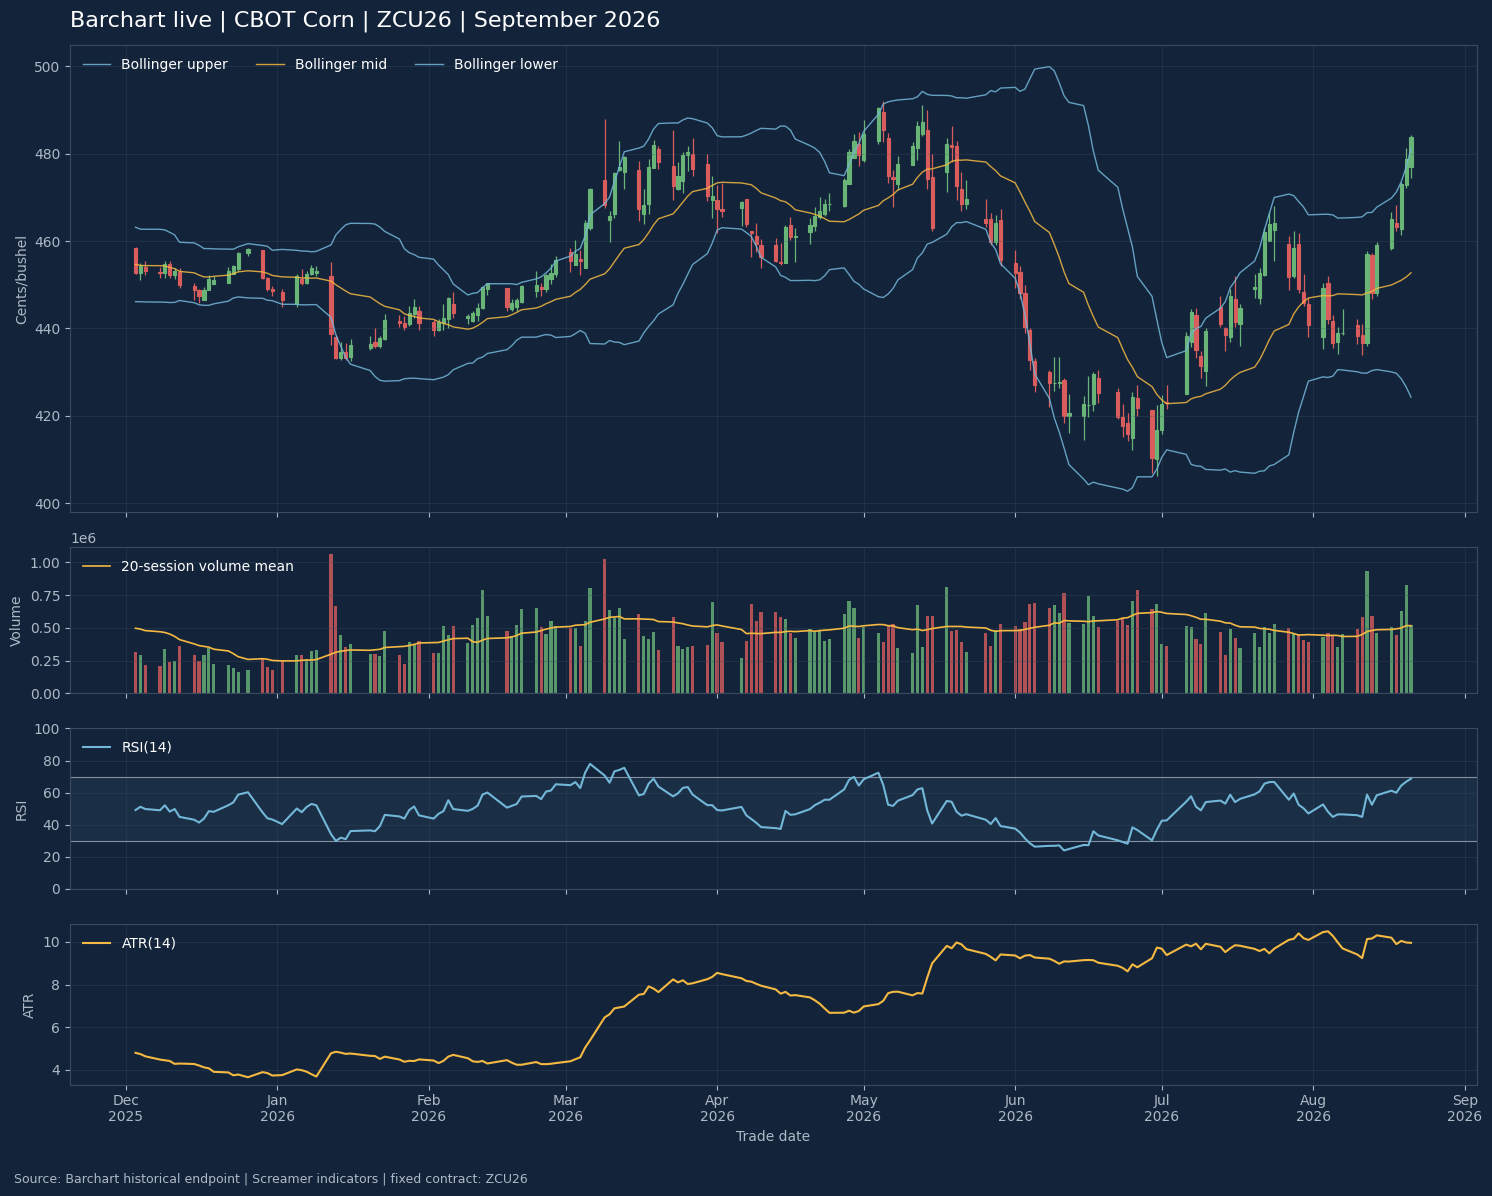

In [3]:
navy = "#13233A"
gold = "#F4B942"
field_green = "#69B578"
red = "#D95D5D"
sky = "#73B7D8"
muted = "#AEB9C6"

plot_data = history.tail(PLOT_SESSIONS).copy()
x_values = mdates.date2num(
    plot_data["date"].to_numpy(dtype="datetime64[ns]")
)
x_step = np.nanmedian(np.diff(x_values))
candle_width = max(float(x_step * 0.65), 0.25)

plt.style.use("dark_background")
fig, axes = plt.subplots(
    4,
    1,
    figsize=(15, 12),
    sharex=True,
    gridspec_kw={"height_ratios": [3.2, 1, 1.1, 1.1]},
)
fig.patch.set_facecolor(navy)
for axis in axes:
    axis.set_facecolor(navy)
    axis.grid(True, color="#3A4A60", alpha=0.35)
    axis.tick_params(colors=muted)
    for spine in axis.spines.values():
        spine.set_color("#3A4A60")

for x_value, (_, row) in zip(x_values, plot_data.iterrows()):
    bullish = row["close"] >= row["open"]
    color = field_green if bullish else red
    axes[0].vlines(x_value, row["low"], row["high"], color=color, linewidth=0.9)
    body_bottom = min(row["open"], row["close"])
    body_height = abs(row["close"] - row["open"])
    body_height = max(body_height, 0.01)
    axes[0].add_patch(
        Rectangle(
            (x_value - candle_width / 2, body_bottom),
            candle_width,
            body_height,
            facecolor=color,
            edgecolor=color,
            linewidth=0.8,
        )
    )

axes[0].plot(
    x_values,
    plot_data["bb_upper"],
    color=sky,
    linewidth=1.0,
    alpha=0.85,
    label="Bollinger upper",
)
axes[0].plot(
    x_values,
    plot_data["bb_mid"],
    color=gold,
    linewidth=1.0,
    alpha=0.85,
    label="Bollinger mid",
)
axes[0].plot(
    x_values,
    plot_data["bb_lower"],
    color=sky,
    linewidth=1.0,
    alpha=0.85,
    label="Bollinger lower",
)
axes[0].set_title(
    "Barchart live | CBOT Corn | ZCU26 | September 2026",
    loc="left",
    color="white",
    fontsize=16,
    pad=14,
)
axes[0].set_ylabel("Cents/bushel", color=muted)
axes[0].legend(frameon=False, labelcolor="white", loc="upper left", ncol=3)

bar_colors = np.where(
    plot_data["close"].to_numpy() >= plot_data["open"].to_numpy(),
    field_green,
    red,
)
axes[1].bar(
    x_values,
    plot_data["volume"],
    width=candle_width,
    color=bar_colors,
    alpha=0.8,
)
axes[1].plot(
    x_values,
    plot_data["volume_mean20"],
    color=gold,
    linewidth=1.2,
    label="20-session volume mean",
)
axes[1].set_ylabel("Volume", color=muted)
axes[1].legend(frameon=False, labelcolor="white", loc="upper left")

axes[2].axhspan(30, 70, color=sky, alpha=0.08)
axes[2].axhline(70, color=muted, linewidth=0.8, alpha=0.7)
axes[2].axhline(30, color=muted, linewidth=0.8, alpha=0.7)
axes[2].plot(
    x_values,
    plot_data["rsi14"],
    color=sky,
    linewidth=1.5,
    label="RSI(14)",
)
axes[2].set_ylim(0, 100)
axes[2].set_ylabel("RSI", color=muted)
axes[2].legend(frameon=False, labelcolor="white", loc="upper left")

axes[3].plot(
    x_values,
    plot_data["atr14"],
    color=gold,
    linewidth=1.5,
    label="ATR(14)",
)
axes[3].set_ylabel("ATR", color=muted)
axes[3].set_xlabel("Trade date", color=muted)
axes[3].legend(frameon=False, labelcolor="white", loc="upper left")

axes[3].xaxis_date()
axes[3].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
fig.text(
    0.01,
    0.01,
    "Source: Barchart historical endpoint | Screamer indicators | fixed contract: ZCU26",
    color=muted,
    fontsize=9,
)
fig.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 3. Recent observations

This table keeps the latest price move and activity visible without mixing
contracts or applying a roll rule.

In [4]:
recent_columns = [
    "date",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "daily_change",
    "daily_return_pct",
    "atr14",
    "rsi14",
]
if "openInterest" in history.columns:
    recent_columns.insert(6, "openInterest")

recent = history.tail(10)[recent_columns].copy()
recent["date"] = recent["date"].dt.strftime("%Y-%m-%d")
display(recent)

,date,open,high,low,close,volume,openInterest,daily_change,daily_return_pct,atr14,rsi14
664,2026-08-10,440.75,442.25,436.50,438.25,489062,1701378.0,-0.75,-0.170843,9.412977,45.948001
665,2026-08-11,438.50,441.00,434.00,436.75,580325,1684065.0,-1.50,-0.342270,9.240622,44.878449
666,2026-08-12,436.75,457.75,436.00,457.00,931069,1684252.0,20.25,4.636520,10.134149,58.815906
667,2026-08-13,456.75,457.25,446.75,448.00,591789,1695859.0,-9.00,-1.969365,10.160281,52.466327
668,2026-08-14,448.00,459.75,447.50,459.00,461322,1706223.0,11.00,2.455357,10.309547,58.380355
669,2026-08-17,458.50,466.75,458.00,465.00,503188,1721535.0,6.00,1.307190,10.198151,61.214941
670,2026-08-18,464.25,468.25,462.25,463.25,441553,1728003.0,-1.75,-0.376344,9.898283,59.932824
671,2026-08-19,462.75,473.50,461.50,473.00,627995,1723684.0,9.75,2.104695,10.048405,64.405837
672,2026-08-20,472.75,481.25,472.25,478.75,827984,1717199.0,5.75,1.215645,9.973519,66.762451
673,2026-08-21,477.00,484.25,474.50,483.75,522817,NaN,5.00,1.044386,9.957554,68.702892


## 4. Agricultural futures universe: current front contracts

The catalog keeps Barchart roots, exchange symbols, venues, units, and
contract-month metadata in Barchart/commoditycatalog.py. The table includes
secondary livestock products; the comparison uses the major default set.

Barchart's "*1" shortcut resolves the current front contract. Each line below
is therefore one fixed contract chosen as of the run date, not a historical
continuous roll. It is rebased to 100 at its first available observation so
contracts with different currencies and units can be compared by direction.

,name,root,category,venue,exchange_symbol,units,contract_months,notes,comparison_default,front_shortcut
0,Corn,ZC,grains,CBOT,ZC,"5,000 bushels",H K N U Z,,True,ZC*1
1,Chicago SRW Wheat,ZW,grains,CBOT,ZW,"5,000 bushels",H K N U Z,,True,ZW*1
2,KC HRW Wheat,KE,grains,CBOT,KE,"5,000 bushels",H K N U Z,,True,KE*1
3,Spring Wheat,MW,grains,MIAX/MWE,MW,"5,000 bushels",H K N U Z,,True,MW*1
4,Hard Red Spring Wheat,KW,grains,CME,KW,"5,000 bushels",H K N U Z,,True,KW*1
5,Oats,ZO,grains,CBOT,ZO,"5,000 bushels",H K N U Z,,True,ZO*1
6,Rough Rice,ZR,grains,CBOT,ZR,"2,000 hundredweight",F H K N U X,,True,ZR*1
7,Euronext Milling Wheat,ML,grains,Euronext Matif,EBM,50 metric tonnes,H K U Z,,True,ML*1
8,Soybeans,ZS,oilseeds,CBOT,ZS,"5,000 bushels",F H K N Q U X,,True,ZS*1
9,Soybean Meal,ZM,oilseeds,CBOT,ZM,100 short tons,F H K N Q U V Z,,True,ZM*1


,root,name,category,front_contract,venue,first_date,last_date,rows
2,KE,KC HRW Wheat,grains,KEU26,CBOT,2024-07-12,2026-08-21,531
4,KW,Hard Red Spring Wheat,grains,KWU26,CME,2025-04-11,2026-08-21,333
7,ML,Euronext Milling Wheat,grains,MLU26,Euronext Matif,2024-01-02,2026-08-21,674
3,MW,Spring Wheat,grains,MWU26,MIAX/MWE,2025-02-05,2026-08-21,388
0,ZC,Corn,grains,ZCU26,CBOT,2024-01-02,2026-08-21,663
5,ZO,Oats,grains,ZOU26,CBOT,2024-01-02,2026-08-21,663
6,ZR,Rough Rice,grains,ZRU26,CBOT,2025-07-14,2026-08-21,280
1,ZW,Chicago SRW Wheat,grains,ZWU26,CBOT,2024-07-12,2026-08-21,531
14,GF,Feeder Cattle,livestock,GFQ26,CME,2025-06-06,2026-08-21,304
15,HE,Lean Hogs,livestock,HEV26,CME,2025-05-14,2026-08-21,320


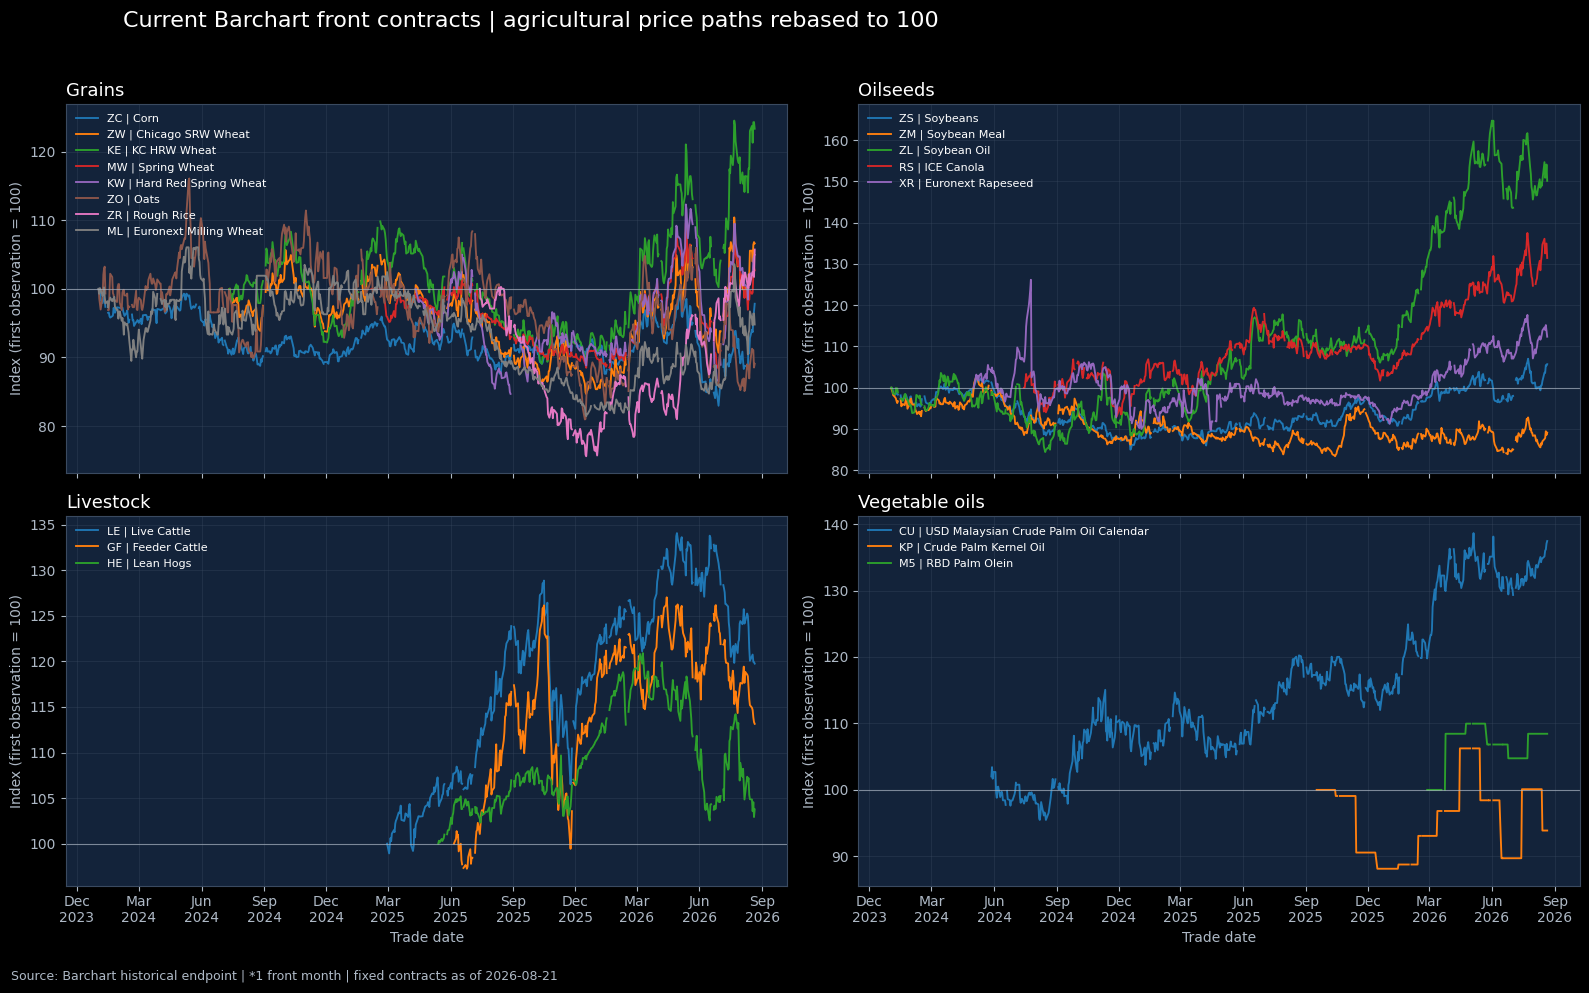

In [5]:
display(catalog_frame())

comparison_start = "2024-01-01"
comparison_end = history["date"].max().strftime("%Y-%m-%d")
comparison_frames = {}
comparison_rows = []
failed_rows = []

for item in agricultural_catalog(comparison_only=True):
    shortcut = item.barchart_symbol()
    try:
        front = client.history(
            shortcut,
            start_date=comparison_start,
            end_date=comparison_end,
            out="df",
        )
        if front.empty or "close" not in front.columns:
            raise ValueError("empty history or missing close column")
        front = front.sort_values("date").reset_index(drop=True)
        actual_symbols = (
            sorted(front["symbol"].dropna().astype(str).unique())
            if "symbol" in front.columns
            else []
        )
        actual_symbol = actual_symbols[-1] if actual_symbols else shortcut
        front = rebase_frame(front)
        comparison_frames[item.root] = front
        valid = front.loc[front["index_100"].notna()]
        comparison_rows.append(
            {
                "root": item.root,
                "name": item.name,
                "category": item.category,
                "front_contract": actual_symbol,
                "venue": item.venue,
                "first_date": valid["date"].iat[0].date(),
                "last_date": valid["date"].iat[-1].date(),
                "rows": len(valid),
            }
        )
    except Exception as exc:
        failed_rows.append(
            {
                "root": item.root,
                "name": item.name,
                "shortcut": shortcut,
                "error": f"{type(exc).__name__}: {exc}",
            }
        )

if not comparison_frames:
    raise RuntimeError("No agricultural front-contract histories were returned.")
front_contracts = pd.DataFrame(comparison_rows).sort_values(["category", "root"])
display(front_contracts)
if failed_rows:
    display(pd.DataFrame(failed_rows))

indexed_history = pd.concat(
    {
        root: frame.set_index("date")["index_100"]
        for root, frame in comparison_frames.items()
    },
    axis=1,
).sort_index()

category_panels = [
    ("grains", "Grains"),
    ("oilseeds", "Oilseeds"),
    ("livestock", "Livestock"),
    ("vegetable_oils", "Vegetable oils"),
]
catalog_by_root = {
    item.root: item for item in agricultural_catalog(comparison_only=True)
}
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
axes = axes.ravel()
colors = plt.get_cmap("tab10").colors

for axis, (category, title) in zip(axes, category_panels):
    axis.set_facecolor(navy)
    axis.grid(True, color="#3A4A60", alpha=0.35)
    axis.tick_params(colors=muted)
    for spine in axis.spines.values():
        spine.set_color("#3A4A60")
    roots = [
        root
        for root in indexed_history.columns
        if catalog_by_root[root].category == category
    ]
    for color_index, root in enumerate(roots):
        item = catalog_by_root[root]
        axis.plot(
            indexed_history.index,
            indexed_history[root],
            linewidth=1.35,
            color=colors[color_index % len(colors)],
            label=f"{root} | {item.name}",
        )
    axis.axhline(100, color=muted, linewidth=0.8, alpha=0.65)
    axis.set_title(title, loc="left", color="white", fontsize=13)
    axis.set_ylabel("Index (first observation = 100)", color=muted)
    axis.legend(frameon=False, labelcolor="white", fontsize=8, loc="best")

axes[2].set_xlabel("Trade date", color=muted)
axes[3].set_xlabel("Trade date", color=muted)
for axis in axes:
    axis.xaxis_date()
    axis.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

fig.suptitle(
    "Current Barchart front contracts | agricultural price paths rebased to 100",
    color="white",
    fontsize=16,
    x=0.08,
    ha="left",
)
fig.text(
    0.01,
    0.01,
    f"Source: Barchart historical endpoint | *1 front month | fixed contracts as of {comparison_end}",
    color=muted,
    fontsize=9,
)
fig.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

## Notes

The [Barchart contract page](https://www.barchart.com/futures/quotes/ZCU26/overview)
identifies this instrument as Corn Sep '26 on the CBOT.

The [Barchart symbol search](https://www.barchart.com/search) documents
futures month codes and nearby shortcuts. "*1" means front month; "*0" means
Barchart's lead month selected using liquidity, so the comparison above uses
"*1" for first nearby.

The catalog covers the major CBOT/CME grains and oilseeds, ICE Canada canola,
Euronext Matif milling wheat and rapeseed, CME livestock, and palm products.
CU is a CME USD wrapper referencing Bursa Malaysia FCPO; KP and M5 are direct
MDEX roots. The indexed chart is a relative price comparison, not a
currency-adjusted return series or a continuous futures series.

Screamer provides causal rolling indicators with the same API for historical
arrays and live streams. The package is used here for Bollinger Bands, ATR,
RSI, and rolling volume mean.

Running this notebook requires internet access and a working Barchart
session. The package does not store credentials.